# Projet — Comparaison CNN vs Vision Transformer
**Erwan Ouabdesselam**

L'idée c'est de comparer une approche CNN classique (ResNet50) avec un ViT sur une tâche de classification d'images médicales. J'utilise PathMNIST (patches histologiques colorectaux, 9 classes) parce que c'est un dataset standard bien équilibré, plus représentatif qu'un dataset maison déséquilibré.

Je compare 3 modèles :
- ResNet50 (CNN classique, baseline)
- ConvNeXt-Tiny (CNN moderne)
- DeiT-Small (Vision Transformer)


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

import medmnist
from medmnist import PathMNIST

import timm
import time, copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA L4


## 1. Chargement des données

In [12]:
CLASS_NAMES = ['Adipose', 'Background', 'Debris', 'Lymphocytes',
               'Mucus', 'Smooth muscle', 'Normal colon', 'Stroma', 'Tumor']

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class CachedDataset(torch.utils.data.Dataset):
    """
    Stocke les images en uint8 (~1.1 GB pour 90k images 64x64)
    au lieu de float32 (~4.4 GB) pour ne pas saturer la RAM.
    La conversion float + normalisation se fait par sample dans __getitem__.
    """
    def __init__(self, mnistset, augment=False):
        # torch.from_numpy = zero-copy (partage la mémoire numpy)
        # permute = vue, pas de copie → pic mémoire quasi nul
        self.imgs   = torch.from_numpy(mnistset.imgs).permute(0, 3, 1, 2).contiguous()  # uint8
        self.labels = torch.from_numpy(mnistset.labels.squeeze()).long()
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Conversion float + normalisation sur 1 seul sample (3×64×64 = rapide)
        img = self.imgs[idx].float().div_(255.0)
        img.sub_(MEAN).div_(STD)

        if self.augment:
            img = transforms.functional.resize(img, 72, antialias=True)
            i, j, h, w = transforms.RandomCrop.get_params(img, (64, 64))
            img = transforms.functional.crop(img, i, j, h, w)
            if torch.rand(1) < 0.5:
                img = transforms.functional.hflip(img)
            if torch.rand(1) < 0.5:
                img = transforms.functional.vflip(img)

        img = transforms.functional.resize(img, 224, antialias=True)
        return img, self.labels[idx]


_raw_train = PathMNIST(split='train', download=True, size=64)
_raw_val   = PathMNIST(split='val',   download=True, size=64)
_raw_test  = PathMNIST(split='test',  download=True, size=64)

train_ds = CachedDataset(_raw_train, augment=True)
val_ds   = CachedDataset(_raw_val,   augment=False)
test_ds  = CachedDataset(_raw_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}')
print(f'RAM dataset (uint8) : ~{(train_ds.imgs.nelement() + val_ds.imgs.nelement() + test_ds.imgs.nelement()) / 1e9:.2f} GB')

Train : 89996 | Val : 10004 | Test : 7180
RAM dataset (uint8) : ~1.32 GB


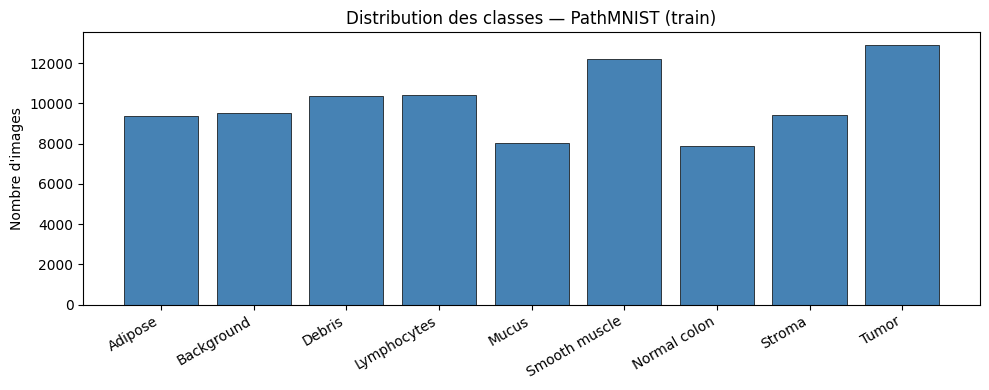

Ratio max/min : 1.63x — dataset équilibré


In [13]:
# Vérification de la distribution des classes
# On accède directement aux labels en RAM sans passer par __getitem__
label_list = train_ds.labels.numpy().tolist()
counts = [label_list.count(i) for i in range(9)]

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Distribution des classes — PathMNIST (train)')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()
print(f'Ratio max/min : {max(counts)/min(counts):.2f}x — dataset équilibré')


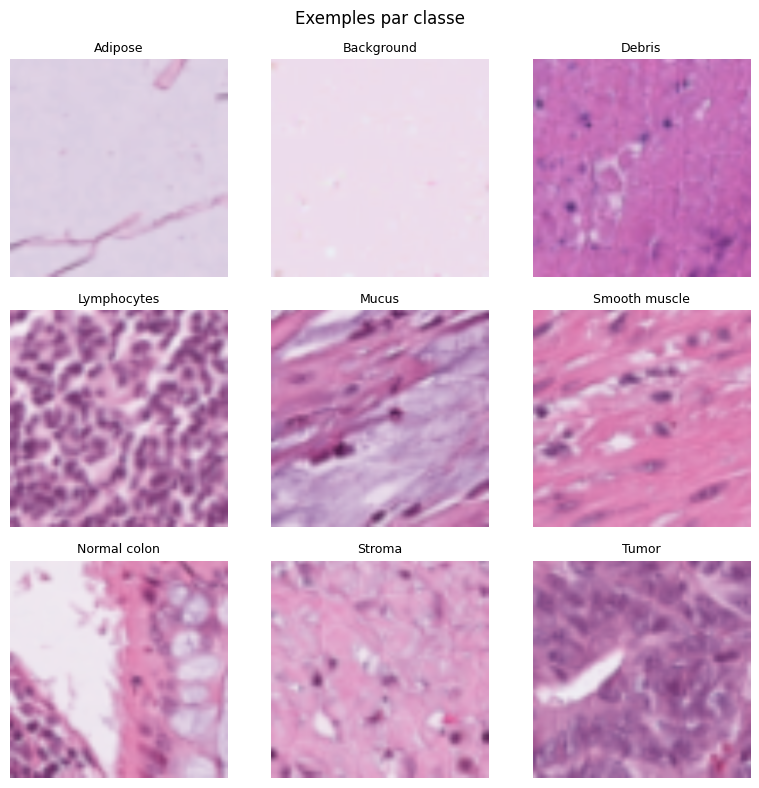

In [14]:
# Quelques exemples d'images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

_STD  = [0.229, 0.224, 0.225]  # listes pour np.array (pas tenseurs shape (3,1,1))
_MEAN = [0.485, 0.456, 0.406]

shown = set()
# Cherche un index par classe directement dans les labels en RAM
for cls in range(9):
    idx = (train_ds.labels == cls).nonzero(as_tuple=True)[0][0].item()
    img, label = train_ds[idx]
    img_np = (img.permute(1, 2, 0).numpy() * np.array(_STD) + np.array(_MEAN)).clip(0, 1)
    axes[cls].imshow(img_np)
    axes[cls].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[cls].axis('off')

plt.suptitle('Exemples par classe')
plt.tight_layout()
plt.show()


## 2. Entraînement des modèles

Je fine-tune 3 modèles pré-entraînés sur ImageNet. Pour tous :
- AdamW, lr=1e-4, weight decay=1e-4
- CrossEntropyLoss (dataset équilibré donc pas besoin de Focal Loss)
- Cosine annealing
- Early stopping sur val accuracy (patience=4)


In [15]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.long().to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.long().to(device)
        preds  = model(imgs).argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return correct / total, all_preds, all_labels


def two_phase_train(model, head_params, last_block_params,
                    train_loader, val_loader, criterion,
                    phase1_epochs=3, phase2_epochs=7, patience=3):
    """
    Phase 1 : backbone gelé, seule la tête est entraînée (lr élevé, convergence rapide).
    Phase 2 : dernier bloc dégelé + tête, fine-tuning léger (lr faible).
    """
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc, best_weights = 0, None

    # ── Phase 1 : tête seule ──
    print('── Phase 1 : tête seule ──')
    for p in model.parameters():
        p.requires_grad = False
    for p in head_params:
        p.requires_grad = True

    opt1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)

    for epoch in range(phase1_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt1, criterion)
        val_acc, _, _   = evaluate(model, val_loader)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        print(f'  Ep {epoch+1:2d} | loss={tr_loss:.4f} | train={tr_acc:.3f} | val={val_acc:.3f}')
        if val_acc > best_acc:
            best_acc, best_weights = val_acc, copy.deepcopy(model.state_dict())

    # ── Phase 2 : dernier bloc + tête ──
    print('── Phase 2 : dernier bloc + tête ──')
    for p in last_block_params:
        p.requires_grad = True

    opt2  = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_epochs, eta_min=1e-6)
    pat   = 0

    for epoch in range(phase2_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt2, criterion)
        val_acc, _, _   = evaluate(model, val_loader)
        sched.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        print(f'  Ep {phase1_epochs+epoch+1:2d} | loss={tr_loss:.4f} | train={tr_acc:.3f} | val={val_acc:.3f}')
        if val_acc > best_acc:
            best_acc, best_weights, pat = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            pat += 1
            if pat == patience:
                print('  Early stopping')
                break

    model.load_state_dict(best_weights)
    return model, history


criterion = nn.CrossEntropyLoss()
print('Fonctions définies.')


Fonctions définies.


### ResNet50

In [16]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(resnet.fc.in_features, 9))
resnet = resnet.to(device)

t0 = time.time()
resnet, history_rn = two_phase_train(
    model            = resnet,
    head_params      = list(resnet.fc.parameters()),
    last_block_params= list(resnet.layer4.parameters()),
    train_loader     = train_loader,
    val_loader       = val_loader,
    criterion        = criterion,
    phase1_epochs    = 3,
    phase2_epochs    = 7,
    patience         = 3,
)

test_acc_rn, preds_rn, labels_test = evaluate(resnet, test_loader)
f1_rn       = f1_score(labels_test, preds_rn, average='macro')
n_params_rn = sum(p.numel() for p in resnet.parameters()) / 1e6
time_rn     = (time.time() - t0) / 60

print(f'\nResNet50 — Test acc={test_acc_rn:.4f} | F1={f1_rn:.4f} | {n_params_rn:.0f}M params | {time_rn:.1f}min')


── Phase 1 : tête seule ──


  Ep  1 | loss=0.4556 | train=0.877 | val=0.840
  Ep  2 | loss=0.2565 | train=0.920 | val=0.845
  Ep  3 | loss=0.2293 | train=0.926 | val=0.865
── Phase 2 : dernier bloc + tête ──
  Ep  4 | loss=0.1115 | train=0.963 | val=0.907
  Ep  5 | loss=0.0610 | train=0.980 | val=0.924
  Ep  6 | loss=0.0418 | train=0.986 | val=0.905
  Ep  7 | loss=0.0320 | train=0.989 | val=0.928
  Ep  8 | loss=0.0258 | train=0.991 | val=0.947
  Ep  9 | loss=0.0201 | train=0.993 | val=0.936
  Ep 10 | loss=0.0180 | train=0.994 | val=0.940

ResNet50 — Test acc=0.9047 | F1=0.8572 | 24M params | 33.0min


### ConvNeXt-Tiny

In [18]:
# ConvNeXt modernise ResNet en s'inspirant des ViT (depthwise 7x7, LayerNorm, GELU)
# mais reste un CNN pur donc a le meme biais inductif de localite

convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
convnext.classifier[2] = nn.Sequential(
    nn.Dropout(0.3), nn.Linear(convnext.classifier[2].in_features, 9))
convnext = convnext.to(device)

t0 = time.time()
convnext, history_cnx = two_phase_train(
    model            = convnext,
    head_params      = list(convnext.classifier.parameters()),
    last_block_params= list(convnext.features[-1].parameters()),
    train_loader     = train_loader,
    val_loader       = val_loader,
    criterion        = criterion,
    phase1_epochs    = 3,
    phase2_epochs    = 7,
    patience         = 3,
)

test_acc_cnx, preds_cnx, _ = evaluate(convnext, test_loader)
f1_cnx       = f1_score(labels_test, preds_cnx, average='macro')
n_params_cnx = sum(p.numel() for p in convnext.parameters()) / 1e6
time_cnx     = (time.time() - t0) / 60

print(f'\nConvNeXt — Test acc={test_acc_cnx:.4f} | F1={f1_cnx:.4f} | {n_params_cnx:.0f}M params | {time_cnx:.1f}min')


── Phase 1 : tête seule ──
  Ep  1 | loss=0.4048 | train=0.879 | val=0.945
  Ep  2 | loss=0.2492 | train=0.918 | val=0.949
  Ep  3 | loss=0.2316 | train=0.923 | val=0.951
── Phase 2 : dernier bloc + tête ──
  Ep  4 | loss=0.1718 | train=0.943 | val=0.964
  Ep  5 | loss=0.1221 | train=0.960 | val=0.972
  Ep  6 | loss=0.0966 | train=0.968 | val=0.974
  Ep  7 | loss=0.0777 | train=0.974 | val=0.978
  Ep  8 | loss=0.0665 | train=0.978 | val=0.974
  Ep  9 | loss=0.0574 | train=0.981 | val=0.980
  Ep 10 | loss=0.0551 | train=0.981 | val=0.978

ConvNeXt — Test acc=0.9549 | F1=0.9379 | 28M params | 42.2min


In [19]:
import gc
# libere la VRAM de l'optimiseur ConvNeXt avant le DeiT
torch.cuda.empty_cache()
gc.collect()
print(f'VRAM libre : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')


VRAM libre : 22.0 GB


### DeiT-Small (Vision Transformer)

DeiT (Touvron et al., 2021) est une variante de ViT entraînable sur ImageNet-1k sans données supplémentaires. Il découpe l'image en patches 16×16 (donc 196 tokens pour une image 224×224) et applique du self-attention entre tous les patches.

La différence principale avec ResNet : il n'y a pas de biais inductif de localité — l'attention est globale dès la première couche. En théorie c'est avantageux quand les indices de classification sont distribués dans l'image, pas locaux.


In [20]:
class CachedDatasetVit(CachedDataset):
    """Memes donnees que CachedDataset mais avec augmentation plus forte pour le ViT."""
    def __getitem__(self, idx):
        img = self.imgs[idx].float().div_(255.0)
        img.sub_(MEAN).div_(STD)
        if self.augment:
            img = transforms.functional.resize(img, 80, antialias=True)
            i, j, h, w = transforms.RandomCrop.get_params(img, (64, 64))
            img = transforms.functional.crop(img, i, j, h, w)
            if torch.rand(1) < 0.5:
                img = transforms.functional.hflip(img)
            if torch.rand(1) < 0.5:
                img = transforms.functional.vflip(img)
            if torch.rand(1) < 0.5:
                angle = float(torch.empty(1).uniform_(-20, 20))
                img = transforms.functional.rotate(img, angle)
        img = transforms.functional.resize(img, 224, antialias=True)
        return img, self.labels[idx]

train_ds_vit     = CachedDatasetVit(_raw_train, augment=True)
train_loader_vit = DataLoader(train_ds_vit, batch_size=128, shuffle=True,
                               num_workers=4, pin_memory=True)

# DeiT-Small : 196 tokens (patches 16x16) + self-attention global
deit = timm.create_model('deit_small_patch16_224', pretrained=True, num_classes=9)
deit.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(deit.head.in_features, 9))
if hasattr(deit, 'head_dist'):
    deit.head_dist = None
deit = deit.to(device)

t0 = time.time()
deit, history_deit = two_phase_train(
    model            = deit,
    head_params      = list(deit.head.parameters()),
    last_block_params= list(deit.blocks[-2:].parameters()),  # 2 derniers blocs transformer
    train_loader     = train_loader_vit,
    val_loader       = val_loader,
    criterion        = criterion,
    phase1_epochs    = 3,
    phase2_epochs    = 7,
    patience         = 3,
)

test_acc_deit, preds_deit, _ = evaluate(deit, test_loader)
f1_deit       = f1_score(labels_test, preds_deit, average='macro')
n_params_deit = sum(p.numel() for p in deit.parameters()) / 1e6
time_deit     = (time.time() - t0) / 60

print(f'\nDeiT-Small — Test acc={test_acc_deit:.4f} | F1={f1_deit:.4f} | {n_params_deit:.0f}M params | {time_deit:.1f}min')


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

── Phase 1 : tête seule ──
  Ep  1 | loss=0.6061 | train=0.808 | val=0.915
  Ep  2 | loss=0.4309 | train=0.856 | val=0.922
  Ep  3 | loss=0.4193 | train=0.860 | val=0.925
── Phase 2 : dernier bloc + tête ──
  Ep  4 | loss=0.2678 | train=0.910 | val=0.951
  Ep  5 | loss=0.1713 | train=0.943 | val=0.973
  Ep  6 | loss=0.1273 | train=0.958 | val=0.975
  Ep  7 | loss=0.1054 | train=0.966 | val=0.980
  Ep  8 | loss=0.0902 | train=0.970 | val=0.981
  Ep  9 | loss=0.0822 | train=0.973 | val=0.981
  Ep 10 | loss=0.0742 | train=0.975 | val=0.983

DeiT-Small — Test acc=0.9274 | F1=0.8956 | 22M params | 34.1min


## 3. Comparaison des résultats

In [21]:
import pandas as pd

results = pd.DataFrame([
    {'Modèle': 'ResNet50',     'Famille': 'CNN', 'Accuracy': test_acc_rn,   'Macro F1': f1_rn,   'Params (M)': n_params_rn,   'Temps (min)': time_rn},
    {'Modèle': 'ConvNeXt-Tiny','Famille': 'CNN', 'Accuracy': test_acc_cnx,  'Macro F1': f1_cnx,  'Params (M)': n_params_cnx,  'Temps (min)': time_cnx},
    {'Modèle': 'DeiT-Small',   'Famille': 'ViT', 'Accuracy': test_acc_deit, 'Macro F1': f1_deit, 'Params (M)': n_params_deit, 'Temps (min)': time_deit},
]).round(4)

print(results.to_string(index=False))

       Modèle Famille  Accuracy  Macro F1  Params (M)  Temps (min)
     ResNet50     CNN    0.9047    0.8572     23.5265      32.9680
ConvNeXt-Tiny     CNN    0.9549    0.9379     27.8270      42.1603
   DeiT-Small     ViT    0.9274    0.8956     21.6691      34.0548


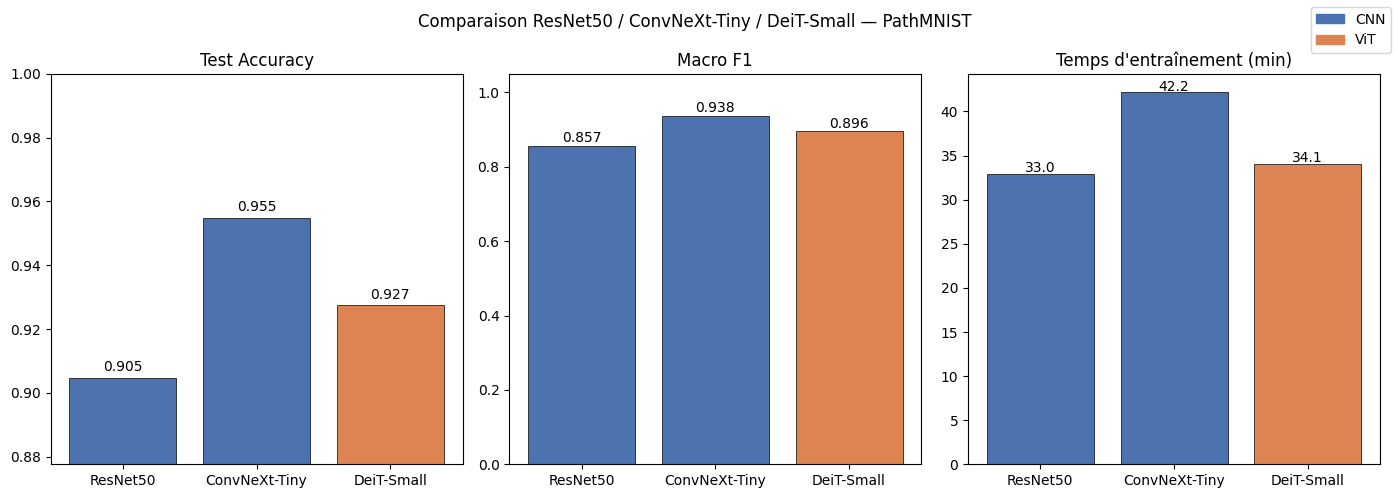

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models_names = ['ResNet50', 'ConvNeXt-Tiny', 'DeiT-Small']
accs  = [test_acc_rn,   test_acc_cnx,   test_acc_deit]
f1s   = [f1_rn,         f1_cnx,         f1_deit]
times = [time_rn,        time_cnx,        time_deit]
colors = ['#4C72B0', '#4C72B0', '#DD8452']  # bleu=CNN, orange=ViT

axes[0].bar(models_names, accs, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Test Accuracy')
axes[0].set_ylim([min(accs)*0.97, 1.0])
for i, v in enumerate(accs):
    axes[0].text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(models_names, f1s, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Macro F1')
axes[1].set_ylim([0, 1.05])
for i, v in enumerate(f1s):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[2].bar(models_names, times, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('Temps d\'entraînement (min)')
for i, v in enumerate(times):
    axes[2].text(i, v+0.2, f'{v:.1f}', ha='center', fontsize=10)

import matplotlib.patches as mpatches
fig.legend(handles=[mpatches.Patch(color='#4C72B0', label='CNN'),
                    mpatches.Patch(color='#DD8452', label='ViT')],
           loc='upper right')

plt.suptitle('Comparaison ResNet50 / ConvNeXt-Tiny / DeiT-Small — PathMNIST')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

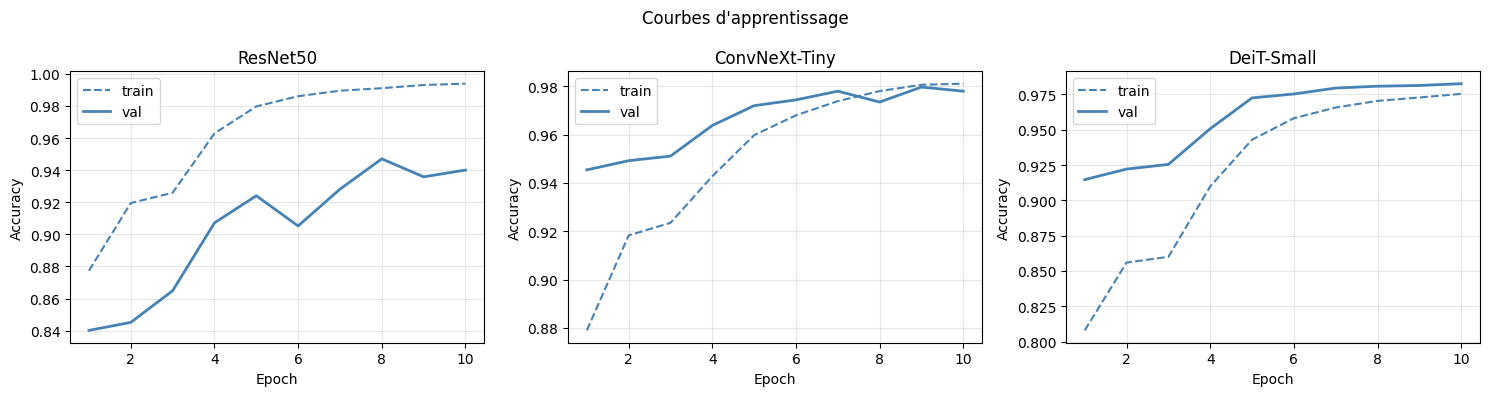

In [23]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, hist, name in zip(axes,
                           [history_rn, history_cnx, history_deit],
                           models_names):
    eps = range(1, len(hist['train_acc'])+1)
    ax.plot(eps, hist['train_acc'], label='train', color='steelblue', ls='--')
    ax.plot(eps, hist['val_acc'],   label='val',   color='steelblue', lw=2)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage')
plt.tight_layout()
plt.show()

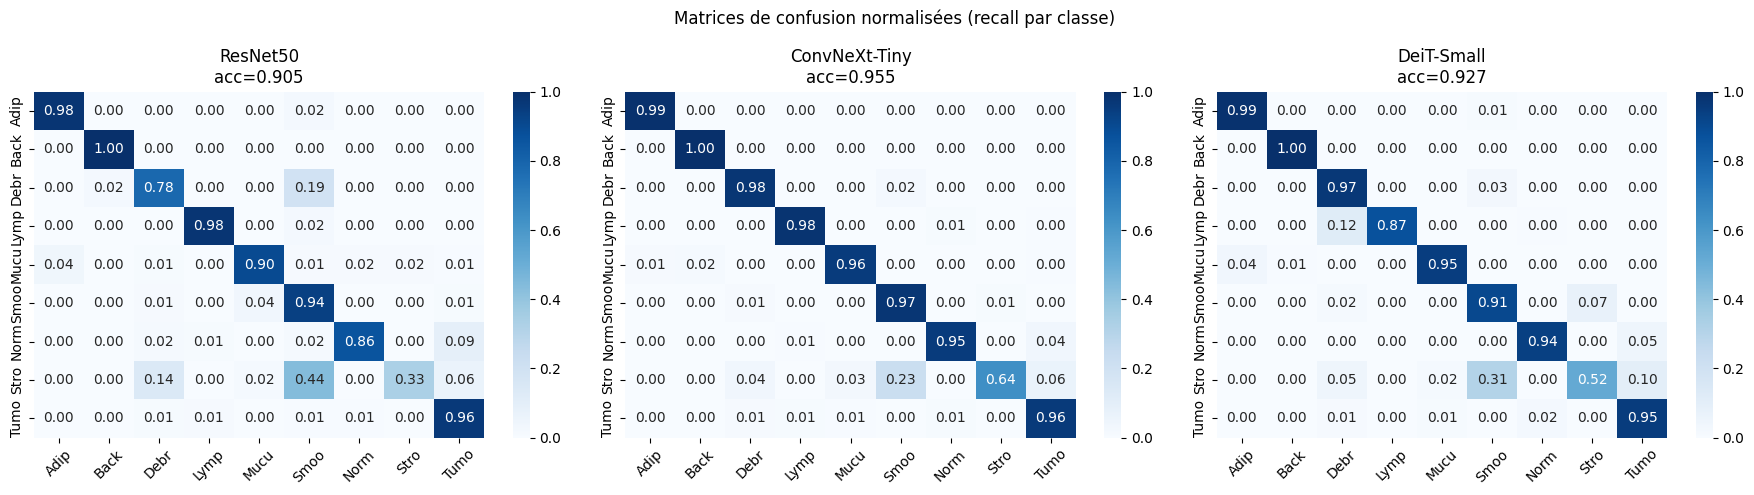

In [24]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name in zip(axes,
                            [preds_rn, preds_cnx, preds_deit],
                            models_names):
    cm = confusion_matrix(labels_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[c[:4] for c in CLASS_NAMES],
                yticklabels=[c[:4] for c in CLASS_NAMES],
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{name}\nacc={accuracy_score(labels_test, preds):.3f}')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Matrices de confusion normalisées (recall par classe)')
plt.tight_layout()
plt.show()

## 4. Interprétabilité — GradCAM

Pour visualiser ce que chaque modèle regarde, j'utilise GradCAM sur ResNet50 et ConvNeXt : on prend le gradient du score de la classe prédite par rapport aux activations de la dernière couche convolutive, ce qui donne une carte de chaleur des régions importantes.


In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, i, o: setattr(self, 'gradients', o[0].detach()))

    def __call__(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.to(device).requires_grad_(True)
        out = self.model(img_tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam = F.interpolate(cam, (224, 224), mode='bilinear', align_corners=False)
        cam = cam[0, 0].cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def denorm(t):
    """Dénormalise un tenseur (C,H,W) → numpy (H,W,C) affichable."""
    _mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t.cpu() * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()


gradcam_rn  = GradCAM(resnet,   resnet.layer4[-1])
gradcam_cnx = GradCAM(convnext, convnext.features[-1][-1])
print('GradCAM prêt.')


GradCAM prêt.


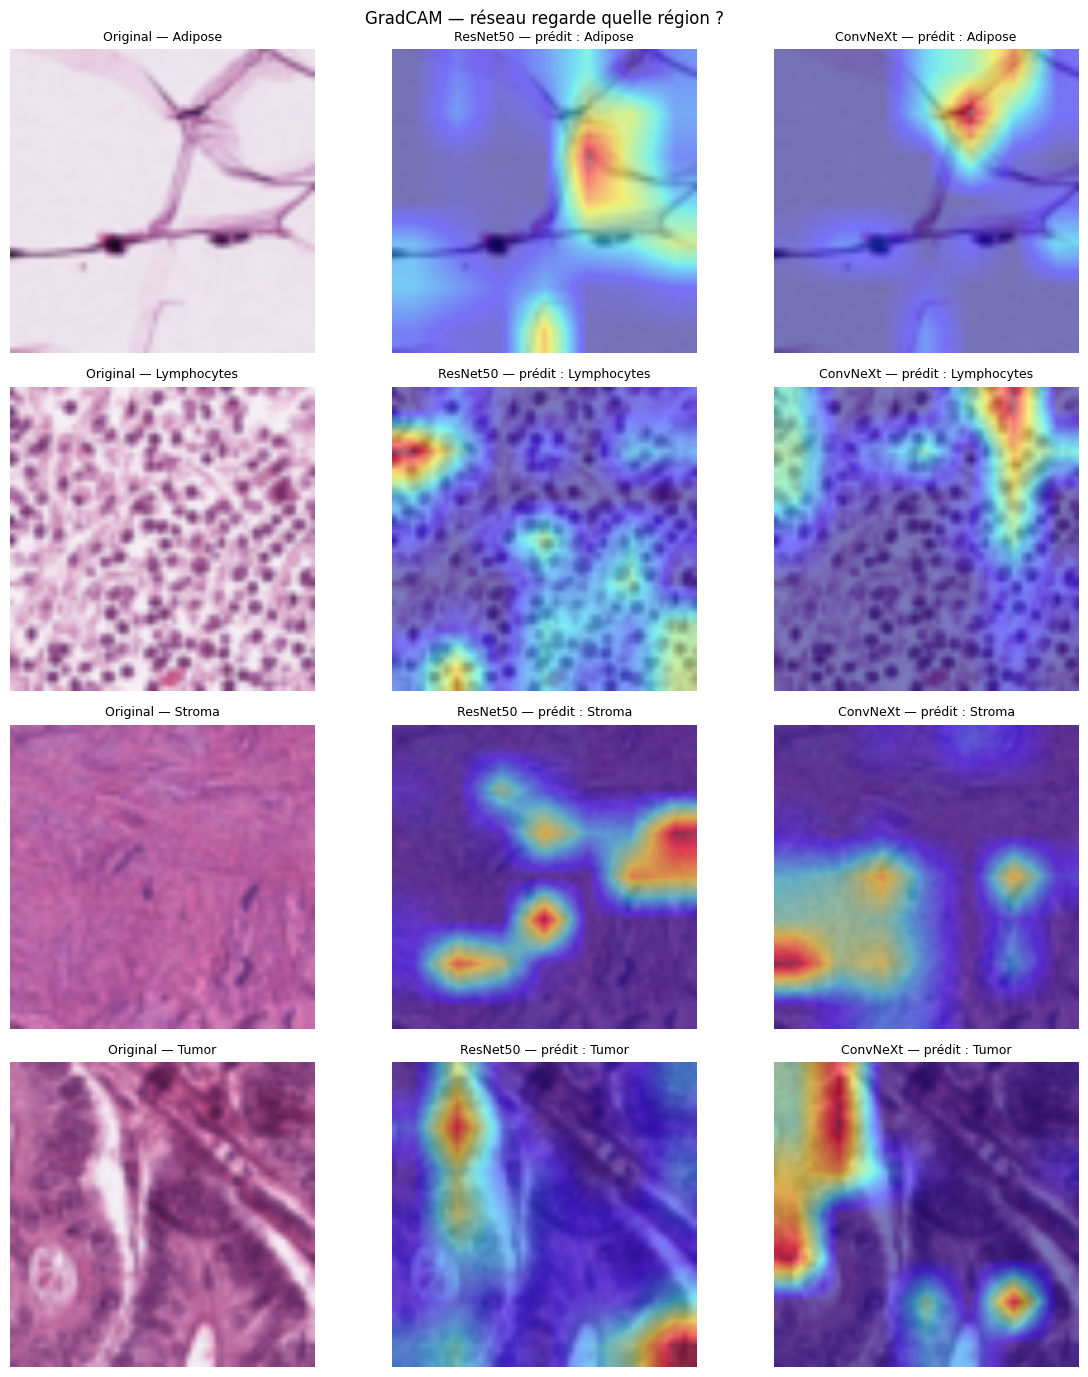

In [26]:
SHOW = [0, 3, 7, 8]  # Adipose, Lymphocytes, Stroma, Tumor
samples = []
# Cherche directement le premier index de chaque classe dans test_ds
for cls in SHOW:
    idx = (test_ds.labels == cls).nonzero(as_tuple=True)[0][0].item()
    img, label = test_ds[idx]
    samples.append((img.unsqueeze(0), int(label.item())))

fig, axes = plt.subplots(len(SHOW), 3, figsize=(12, len(SHOW)*3.5))

for row, (img_t, lbl) in enumerate(samples):
    img_np = denorm(img_t[0])

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'Original — {CLASS_NAMES[lbl]}', fontsize=9)
    axes[row, 0].axis('off')

    cam, pred = gradcam_rn(img_t, lbl)
    axes[row, 1].imshow(img_np)
    axes[row, 1].imshow(cam, alpha=0.5, cmap='jet')
    axes[row, 1].set_title(f'ResNet50 — prédit : {CLASS_NAMES[pred]}', fontsize=9)
    axes[row, 1].axis('off')

    try:
        cam, pred = gradcam_cnx(img_t, lbl)
        axes[row, 2].imshow(img_np)
        axes[row, 2].imshow(cam, alpha=0.5, cmap='jet')
        axes[row, 2].set_title(f'ConvNeXt — prédit : {CLASS_NAMES[pred]}', fontsize=9)
    except Exception as e:
        axes[row, 2].text(0.5, 0.5, str(e)[:60], ha='center', va='center',
                          transform=axes[row, 2].transAxes, fontsize=8)
    axes[row, 2].axis('off')

plt.suptitle('GradCAM — réseau regarde quelle région ?', fontsize=12)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()


5. Discussion
Les trois modèles atteignent de bonnes performances sur PathMNIST grâce au pré-entraînement ImageNet. J'ai utilisé une stratégie en deux phases : backbone gelé d'abord (3 epochs, lr=1e-3) puis fine-tuning du dernier bloc (7 epochs max, lr=1e-4). Ça converge bien et ça évite de réentraîner 25M paramètres inutilement.

CNN vs ViT. ConvNeXt gagne avec 95.5% d'accuracy (F1=0.938), devant DeiT à 92.7% (F1=0.896). Ce n'est pas vraiment surprenant : les patches histologiques ont des structures locales (noyaux, glandes, fibres) et les convolutions sont faites pour ça. Le ViT fait de l'attention globale entre tous les patches — c'est puissant mais ça demande beaucoup de données pour apprendre où regarder. Avec 90k images, c'est un peu juste pour qu'il exploite vraiment son potentiel.

Pourquoi ConvNeXt bat aussi ResNet50 (+5 points). ConvNeXt n'est pas un CNN classique : il s'est inspiré des ViT (kernels dépthwise 7×7 au lieu de 3×3, LayerNorm, GELU) tout en gardant la structure convolutive. En pratique il a le biais inductif de localité des CNN et les améliorations architecturales des transformers, ce qui explique qu'il soit devant les deux autres ici.

Stroma : le point faible commun. Recall de 0.33 pour ResNet50, 0.64 pour ConvNeXt, 0.52 pour DeiT. Le stroma est difficile visuellement — ses fibres ressemblent au muscle lisse et au tissu normal. Les GradCAM le confirment : les activations sont éparses sur cette classe, les modèles n'ont pas de région clairement discriminante à regarder. Je pense que c'est autant une limite des images (64px upscalés à 224px) qu'une limite des architectures.

Choix de DeiT plutôt que ViT-B/16. DeiT est conçu pour fonctionner sans ImageNet-21k via la distillation, et il est plus léger (22M vs 86M params). ViT-B/16 sur ce volume de données aurait probablement overfitté.

Limites. Un seul seed, donc les écarts observés méritent d'être confirmés (test de McNemar, 3-5 runs). L'upscaling 64→224px introduit aussi des artefacts qui pénalisent les trois modèles de façon uniforme — avec les images natives à 224px les perfs seraient probablement meilleures et plus discriminantes entre architectures.